In [2]:
import os
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

In [3]:
encoder=OneHotEncoder()
encoder.fit([[0],[1]])

OneHotEncoder()

In [4]:
data = []
paths = []
result = []

for r, d, f in os.walk(r'/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train/Tumor'):
    for file in f:
        if '.jpg' in file:
            paths.append(os.path.join(r, file))

for path in paths:
    img = Image.open(path)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray())

In [5]:
paths = []
for r, d, f in os.walk(r"/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train/Without_Tumor"):
    for file in f:
        if '.jpg' in file:
            paths.append(os.path.join(r, file))

for path in paths:
    img = Image.open(path)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray())

In [6]:
data = np.array(data)
data.shape

(2935, 128, 128, 3)

In [7]:
result=np.array(result)
result.shape

(2935, 1, 2)

In [8]:
result = np.array(result)

result = result.reshape(2935,2)

In [9]:
result.shape

(2935, 2)

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_temp,y_train,y_temp=train_test_split(data,result, test_size=0.2, random_state=32, shuffle=True)
x_val,x_test,y_val,y_test=train_test_split(x_temp,y_temp, test_size=0.5, random_state=32, shuffle=True)

In [17]:
y_val.shape

(293, 2)

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(2, 2), input_shape=(128, 128, 3), padding = 'Same'))
model.add(Conv2D(32, kernel_size=(2, 2),  activation ='relu', padding = 'Same'))


model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

model.compile(loss = "categorical_crossentropy", optimizer='Adamax', metrics=['accuracy'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      416       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      4128      
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 64, 64, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        8

In [ ]:
history = model.fit(x_train, y_train, epochs = 30, batch_size = 40, verbose = 1,validation_data = (x_val, y_val))

Epoch 1/30
59/59 [==============================] - 193s 3s/step - loss: 0.0039 - accuracy: 0.9979 - val_loss: 0.1900 - val_accuracy: 0.9590
Epoch 2/30
59/59 [==============================] - 174s 3s/step - loss: 0.0039 - accuracy: 0.9991 - val_loss: 0.1722 - val_accuracy: 0.9727
Epoch 3/30
59/59 [==============================] - 170s 3s/step - loss: 0.0053 - accuracy: 0.9983 - val_loss: 0.1832 - val_accuracy: 0.9556
Epoch 4/30
59/59 [==============================] - 166s 3s/step - loss: 0.0040 - accuracy: 0.9991 - val_loss: 0.1831 - val_accuracy: 0.9556
Epoch 5/30
59/59 [==============================] - 168s 3s/step - loss: 0.0027 - accuracy: 0.9996 - val_loss: 0.1816 - val_accuracy: 0.9590
Epoch 6/30
59/59 [==============================] - 170s 3s/step - loss: 0.0024 - accuracy: 0.9996 - val_loss: 0.1694 - val_accuracy: 0.9590
Epoch 7/30
59/59 [==============================] - 165s 3s/step - loss: 0.0021 - accuracy: 0.9991 - val_loss: 0.1918 - val_accuracy: 0.9693
Epoch 8/30
59

In [ ]:
def names(number):
    if number==0:
        return 'Its a Tumor'
    else:
        return 'No, Its not a tumor'

98.31821918487549% Confidence This Is Its a Tumor


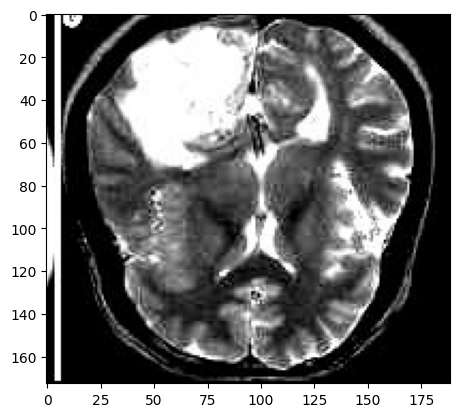

In [ ]:
from matplotlib.pyplot import imshow
img = Image.open(r"/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/Tumor/y9.jpg")
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100) + '% Confidence This Is ' + names(classification))

99.9997615814209% Confidence This Is A No, Its not a tumor


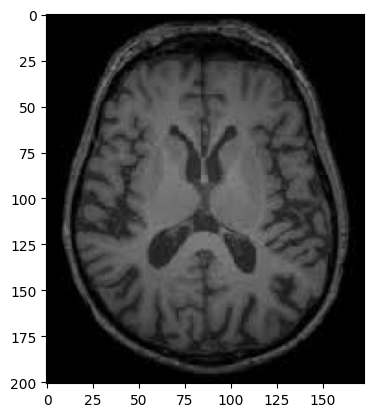

In [ ]:
from matplotlib.pyplot import imshow
img = Image.open(r"/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/Without_Tumor/10 no.jpg")
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100) + '% Confidence This Is A ' + names(classification))

In [ ]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

10/10 [==============================] - 5s 513ms/step


array([1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0])

In [ ]:
y_test

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.

In [ ]:
true_labels = np.argmax(y_test, axis=1)
true_labels

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0])

In [ ]:
confusion_mat = confusion_matrix(true_labels, predicted_labels)

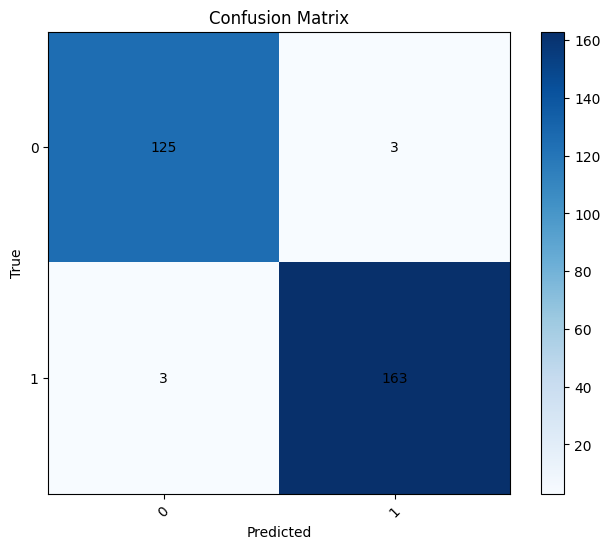

In [ ]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_mat, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

# Add labels to the confusion matrix
num_classes = len(np.unique(true_labels))
classes = [str(i) for i in range(num_classes)]
plt.xticks(np.arange(num_classes), classes, rotation=45)
plt.yticks(np.arange(num_classes), classes)

# Display the values in the confusion matrix
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, confusion_mat[i, j], ha='center', va='center', color='black')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

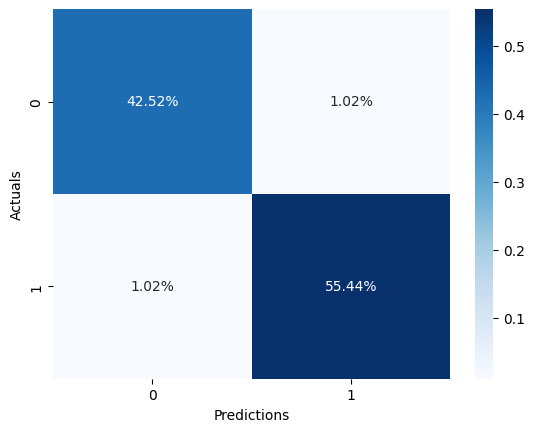

In [ ]:
sns.heatmap(confusion_mat/np.sum(confusion_mat), annot=True,
            fmt='.2%', cmap='Blues')
plt.ylabel('Actuals')
plt.xlabel('Predictions')
plt.show()

In [ ]:
#Finding precision and Recall
accuracy=accuracy_score(true_labels,predicted_labels)
print("Accuracy: ", accuracy)
precision=precision_score(true_labels,predicted_labels)
print("Precision: ", precision)
recall=recall_score(true_labels,predicted_labels)
print("Recall: ", recall)
F1_score=f1_score(true_labels,predicted_labels)
print("F1-score: ", F1_score)
auc_score=roc_auc_score(true_labels,predicted_labels)
print("AUC-score: ", auc_score)
loss=model.evaluate(x_test,y_test)
print('Loss: ',loss)

Accuracy:  0.9795918367346939
Precision:  0.9819277108433735
Recall:  0.9819277108433735
F1-score:  0.9819277108433735
AUC-score:  0.9792451054216867
10/10 [==============================] - 5s 446ms/step - loss: 0.1256 - accuracy: 0.9796
Loss:  [0.12560541927814484, 0.9795918464660645]


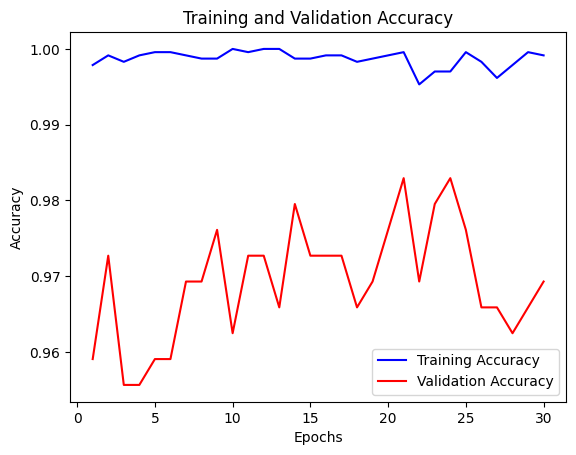

In [ ]:
# Extract training and validation accuracy from history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Create an array of the epoch numbers
epochs = range(1, len(train_accuracy) + 1)

# Plot the training and validation accuracy curves
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

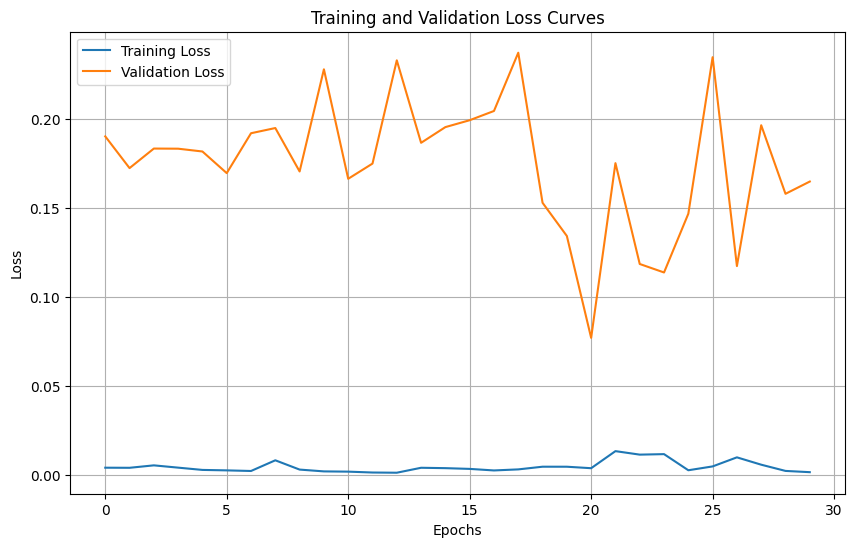

In [ ]:
# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
accuracy=accuracy_score(true_labels, predicted_labels)
print(f'Accuracy: {accuracy*100:.2f}%')

Accuracy: 97.96%


In [ ]:
import matplotlib.pyplot as plt

# Example AUC values (replace with your actual AUC scores)
train_auc_values = []
val_auc_values = []

In [ ]:
epochs = 30  # Adjust this based on your needs
for epoch in range(epochs):
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=1, verbose=0)

    # Calculate AUC for training and validation data
    y_train_pred =model.predict(x_train)
    train_auc= roc_auc_score(y_train, y_train_pred)
    train_auc_values.append(train_auc)

    y_val_pred =model.predict(x_val)
    val_auc = roc_auc_score(y_val, y_val_pred)
    val_auc_values.append(val_auc)

    print(f'Epoch {epoch + 1}, Train AUC: {train_auc}, Validation AUC: {val_auc}')

10/10 [==============================] - 4s 386ms/step
Epoch 1, Train AUC: 0.9999172225703554, Validation AUC: 0.995479962721342
10/10 [==============================] - 6s 591ms/step
Epoch 2, Train AUC: 0.9997091898195379, Validation AUC: 0.9953052190121157
10/10 [==============================] - 4s 382ms/step
Epoch 3, Train AUC: 0.9997444065330271, Validation AUC: 0.9955731593662628
10/10 [==============================] - 4s 385ms/step
Epoch 4, Train AUC: 0.9998299069044363, Validation AUC: 0.9949324324324325
10/10 [==============================] - 6s 586ms/step
Epoch 5, Train AUC: 0.9996461991000496, Validation AUC: 0.993790773532153
10/10 [==============================] - 5s 503ms/step
Epoch 6, Train AUC: 0.9998132061949467, Validation AUC: 0.9958061509785647
10/10 [==============================] - 4s 397ms/step
Epoch 7, Train AUC: 0.9998876332698464, Validation AUC: 0.9963187325256291
10/10 [==============================] - 4s 384ms/step
Epoch 8, Train AUC: 0.999567959906679

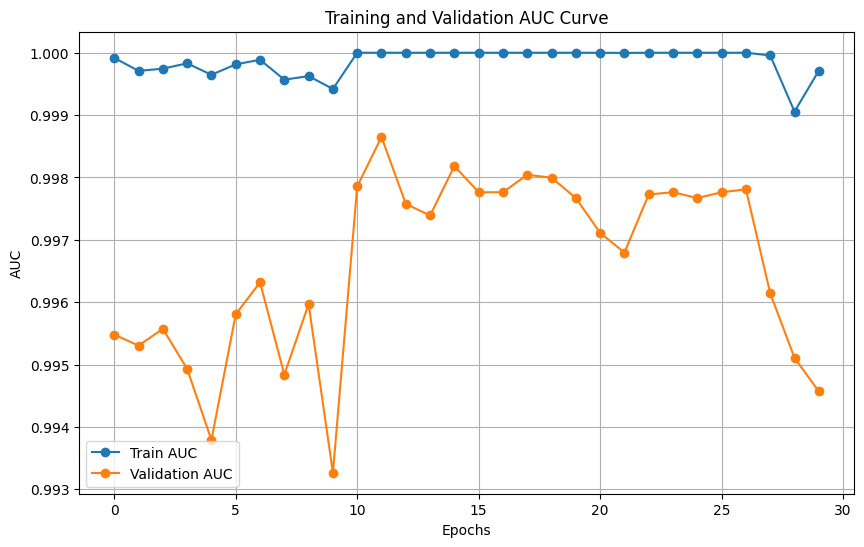

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_auc_values, label='Train AUC', marker='o')
plt.plot(range(epochs), val_auc_values, label='Validation AUC', marker='o')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training and Validation AUC Curve')
plt.legend()
plt.grid(True)
plt.show()